In [1]:
# ==========================================
# Ejemplo simple de red neuronal con Keras
# ==========================================

# 1️⃣ Importar las librerías necesarias
import tensorflow as tf                     # Framework de Deep Learning
from tensorflow import keras                # API de alto nivel para construir modelos
from tensorflow.keras import layers         # Capas básicas de redes neuronales
import numpy as np                          # Para manipular datos numéricos


In [2]:
# 2️⃣ Cargar un dataset de ejemplo (MNIST)
# MNIST son imágenes de dígitos escritos a mano (0–9)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# 3️⃣ Preprocesamiento de datos
# Convertimos los valores de los píxeles (0–255) a flotantes entre 0 y 1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
# Aplanamos las imágenes 28x28 → vectores de 784 elementos
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [5]:
# 4️⃣ Definir el modelo
# Creamos una red neuronal simple con:
# - Capa oculta de 128 neuronas (ReLU)
# - Capa de salida de 10 neuronas (Softmax)
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),  # Capa oculta
    layers.Dense(10, activation='softmax')                     # Capa de salida (10 clases)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# 5️⃣ Compilar el modelo
# Definimos:
# - Optimización: Adam (común y eficiente)
# - Pérdida: entropía cruzada (para clasificación)
# - Métrica: exactitud (accuracy)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# 6️⃣ Entrenar el modelo
# Entrenamos durante 5 épocas (pasadas completas por el dataset)
# batch_size=32 significa que actualiza pesos cada 32 imágenes
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8668 - loss: 0.4669 - val_accuracy: 0.9663 - val_loss: 0.1182
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9608 - loss: 0.1319 - val_accuracy: 0.9717 - val_loss: 0.1003
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9755 - loss: 0.0813 - val_accuracy: 0.9753 - val_loss: 0.0815
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9821 - loss: 0.0615 - val_accuracy: 0.9757 - val_loss: 0.0848
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9855 - loss: 0.0469 - val_accuracy: 0.9772 - val_loss: 0.0828


In [8]:
# 7️⃣ Evaluar el modelo en datos nuevos (test)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Exactitud en el conjunto de prueba: {test_acc:.3f}")

Exactitud en el conjunto de prueba: 0.975


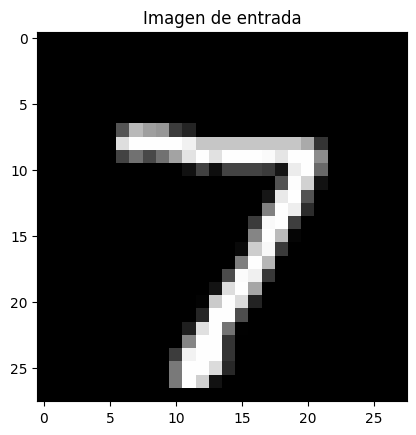

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Probabilidades por clase: [[1.7446310e-07 4.0458064e-09 1.7030599e-05 9.8190934e-04 2.2965818e-12
  1.0340934e-07 9.6488026e-11 9.9899668e-01 2.2163039e-07 3.9567185e-06]]
Clase predicha: 7


In [11]:
# 8️⃣ Realizar una predicción de ejemplo
# Seleccionamos una imagen de prueba y predecimos su clase
import matplotlib.pyplot as plt

i = 0  # índice de la imagen a predecir
plt.imshow(X_test[i].reshape(28,28), cmap='gray')
plt.title("Imagen de entrada")
plt.show()

# El modelo devuelve probabilidades para cada clase (0-9)
pred = model.predict(X_test[i].reshape(1, 784))
print("Probabilidades por clase:", pred)
print("Clase predicha:", np.argmax(pred))